# CORES-IoT Dataset - Feature Analysis & Data Cleaning

This notebook provides comprehensive analysis of the CORES-IoT dataset:
1. Data Overview & Basic Statistics
2. Missing Values Analysis
3. Duplicate Detection
4. Class Distribution & Imbalance
5. Feature Distribution Analysis
6. Correlation Analysis
7. Outlier Detection
8. Feature Importance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Load Data

In [2]:
# The CORES-IoT dataset has 19 features + 1 label (ANOMALY)
N_FEATURES = 19
COLUMN_NAMES = [f'feature_{i}' for i in range(N_FEATURES)] + ['ANOMALY']

# Load data
data_path = Path('../../datasets/raw/cores-iot/cores_iot.csv')

print("Loading CORES-IoT data...")
df = pd.read_csv(data_path, names=COLUMN_NAMES, header=None)
print(f"Total samples: {len(df):,}")

Loading CORES-IoT data...
Total samples: 1,008,748


In [3]:
# Quick overview
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nShape: {df.shape}")
print(f"\nColumn types:")
print(df.dtypes.value_counts())
df.head()

DATASET OVERVIEW

Shape: (1008748, 20)

Column types:
float64    19
int64       1
Name: count, dtype: int64


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,ANOMALY
0,611504.0,6478.0,2168.0,522479.0,63298.0,1.0,0.0,2599.0,1.0,1.0,1.0,0.0,0.0,0.0,118.0,1.0,939.0,1.0,893.0,1
1,966663.0,6478.0,13397.0,506713.0,14426.0,1.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,22.0,1.0,939.0,0.0,0.0,1
2,23313.0,6478.0,11001.0,526438.0,18556.0,2.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,2.0,1.0,807.0,0.0,0.0,0
3,204100.0,6478.0,11001.0,470169.0,2386.0,2.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,2.0,1.0,807.0,0.0,0.0,0
4,493724.0,6478.0,23327.0,510129.0,63298.0,1.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,22.0,1.0,939.0,0.0,0.0,1


In [4]:
# Check data types
print("\nData types per column:")
print(df.dtypes)


Data types per column:
feature_0     float64
feature_1     float64
feature_2     float64
feature_3     float64
feature_4     float64
feature_5     float64
feature_6     float64
feature_7     float64
feature_8     float64
feature_9     float64
feature_10    float64
feature_11    float64
feature_12    float64
feature_13    float64
feature_14    float64
feature_15    float64
feature_16    float64
feature_17    float64
feature_18    float64
ANOMALY         int64
dtype: object


## 2. Missing Values Analysis

In [5]:
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

if missing.sum() == 0:
    print("\nNo missing values found!")
else:
    print(f"\nTotal missing values: {missing.sum()}")
    missing_df = pd.DataFrame({'missing': missing, 'percentage': missing_pct})
    print(missing_df[missing_df['missing'] > 0])

MISSING VALUES ANALYSIS

No missing values found!


In [6]:
# Check for infinite values
print("\n--- Checking for Infinite Values ---")
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_count = np.isinf(df[numeric_cols]).sum().sum()

if inf_count == 0:
    print("No infinite values found!")
else:
    print(f"Found {inf_count} infinite values")
    for col in numeric_cols:
        col_inf = np.isinf(df[col]).sum()
        if col_inf > 0:
            print(f"  {col}: {col_inf}")


--- Checking for Infinite Values ---
No infinite values found!


In [7]:
# Check for zeros (might indicate missing data in some contexts)
print("\n--- Zero Value Analysis ---")
zero_counts = (df == 0).sum()
zero_pct = (zero_counts / len(df)) * 100

zero_df = pd.DataFrame({'zeros': zero_counts, 'percentage': zero_pct}).sort_values('percentage', ascending=False)
print("Features with highest zero percentages:")
print(zero_df.head(10).to_string())


--- Zero Value Analysis ---
Features with highest zero percentages:
              zeros  percentage
feature_12  1008748  100.000000
feature_13  1008748  100.000000
feature_11  1008748  100.000000
feature_6   1005507   99.678711
feature_17   988854   98.027852
feature_18   988854   98.027852
feature_8    796300   78.939438
feature_7    796300   78.939438
feature_9    796300   78.939438
ANOMALY      469275   46.520538


## 3. Duplicate Detection

In [8]:
print("=" * 60)
print("DUPLICATE ANALYSIS")
print("=" * 60)

# Full duplicates
dup_count = df.duplicated().sum()
dup_pct = (dup_count / len(df)) * 100

print(f"\nExact duplicates: {dup_count:,} ({dup_pct:.2f}%)")

# Duplicates excluding label
feature_cols = [c for c in df.columns if c != 'ANOMALY']
dup_features = df[feature_cols].duplicated().sum()
dup_features_pct = (dup_features / len(df)) * 100
print(f"Duplicates (features only): {dup_features:,} ({dup_features_pct:.2f}%)")

# Check for conflicting duplicates (same features, different labels)
dup_mask = df.duplicated(subset=feature_cols, keep=False)
if dup_mask.any():
    conflicting = df[dup_mask].groupby(feature_cols)['ANOMALY'].nunique()
    conflicts = (conflicting > 1).sum()
    print(f"\nConflicting duplicates (same features, different labels): {conflicts}")

DUPLICATE ANALYSIS

Exact duplicates: 0 (0.00%)
Duplicates (features only): 0 (0.00%)


## 4. Class Distribution & Imbalance

In [9]:
print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

class_dist = df['ANOMALY'].value_counts()
class_pct = df['ANOMALY'].value_counts(normalize=True) * 100

print(f"\nClass Distribution:")
print(f"  Normal (0):  {class_dist.get(0, 0):>10,} ({class_pct.get(0, 0):.2f}%)")
print(f"  Attack (1):  {class_dist.get(1, 0):>10,} ({class_pct.get(1, 0):.2f}%)")

# Calculate imbalance ratio
if class_dist.get(0, 0) > 0 and class_dist.get(1, 0) > 0:
    ratio = max(class_dist) / min(class_dist)
    print(f"\nImbalance ratio: {ratio:.2f}:1")

CLASS DISTRIBUTION

Class Distribution:
  Normal (0):     469,275 (46.52%)
  Attack (1):     539,473 (53.48%)

Imbalance ratio: 1.15:1


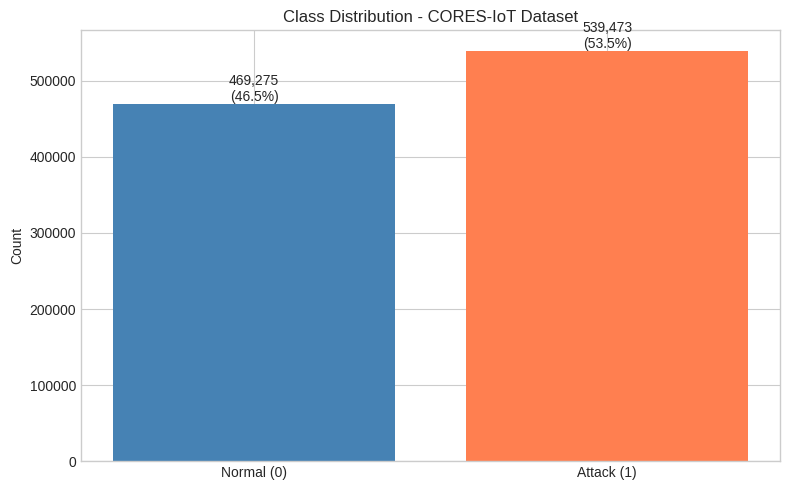

In [10]:
# Visualize class distribution
fig, ax = plt.subplots(figsize=(8, 5))

labels = ['Normal (0)', 'Attack (1)']
values = [class_dist.get(0, 0), class_dist.get(1, 0)]
colors = ['steelblue', 'coral']

bars = ax.bar(labels, values, color=colors)
ax.set_ylabel('Count')
ax.set_title('Class Distribution - CORES-IoT Dataset')

# Add value labels on bars
for bar, val, pct in zip(bars, values, [class_pct.get(0, 0), class_pct.get(1, 0)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 5. Feature Distribution Analysis

In [11]:
print("=" * 60)
print("FEATURE STATISTICS")
print("=" * 60)

feature_cols = [c for c in df.columns if c != 'ANOMALY']
stats = df[feature_cols].describe().T
stats['range'] = stats['max'] - stats['min']
stats['cv'] = stats['std'] / stats['mean']  # Coefficient of variation
print(stats)

FEATURE STATISTICS
                count           mean            std  min        25%       50%  \
feature_0   1008748.0  504373.500000  291200.609010  0.0  252186.75  504373.5   
feature_1   1008748.0    6494.011871     555.264176  0.0    6478.00    6478.0   
feature_2   1008748.0   12526.659091    6702.988607  0.0   10969.75   11001.0   
feature_3   1008748.0  294516.576063  173568.914939  0.0  144681.00  279811.5   
feature_4   1008748.0   31092.356291   21509.502706  0.0   14426.00   18598.0   
feature_5   1008748.0       1.387383       0.521400  0.0       1.00       1.0   
feature_6   1008748.0       0.009637       0.169756  0.0       0.00       0.0   
feature_7   1008748.0    2534.523978    5058.343898  0.0       0.00       0.0   
feature_8   1008748.0       1.720590      12.591445  0.0       0.00       0.0   
feature_9   1008748.0       3.806326      34.694888  0.0       0.00       0.0   
feature_10  1008748.0       5.912600       0.924476  0.0       6.00       6.0   
feature_1

In [12]:
# Check for zero-variance or near-zero variance features
print("\n--- Zero/Low Variance Features ---")
variances = df[feature_cols].var()
unique_counts = df[feature_cols].nunique()

low_var_features = []
for col in feature_cols:
    var = variances[col]
    unique = unique_counts[col]
    if unique <= 2 or var < 0.01:
        print(f"{col}: variance={var:.6f}, unique={unique}")
        low_var_features.append(col)

if not low_var_features:
    print("No zero/low variance features found.")


--- Zero/Low Variance Features ---
feature_11: variance=0.000000, unique=1
feature_12: variance=0.000000, unique=1
feature_13: variance=0.000000, unique=1


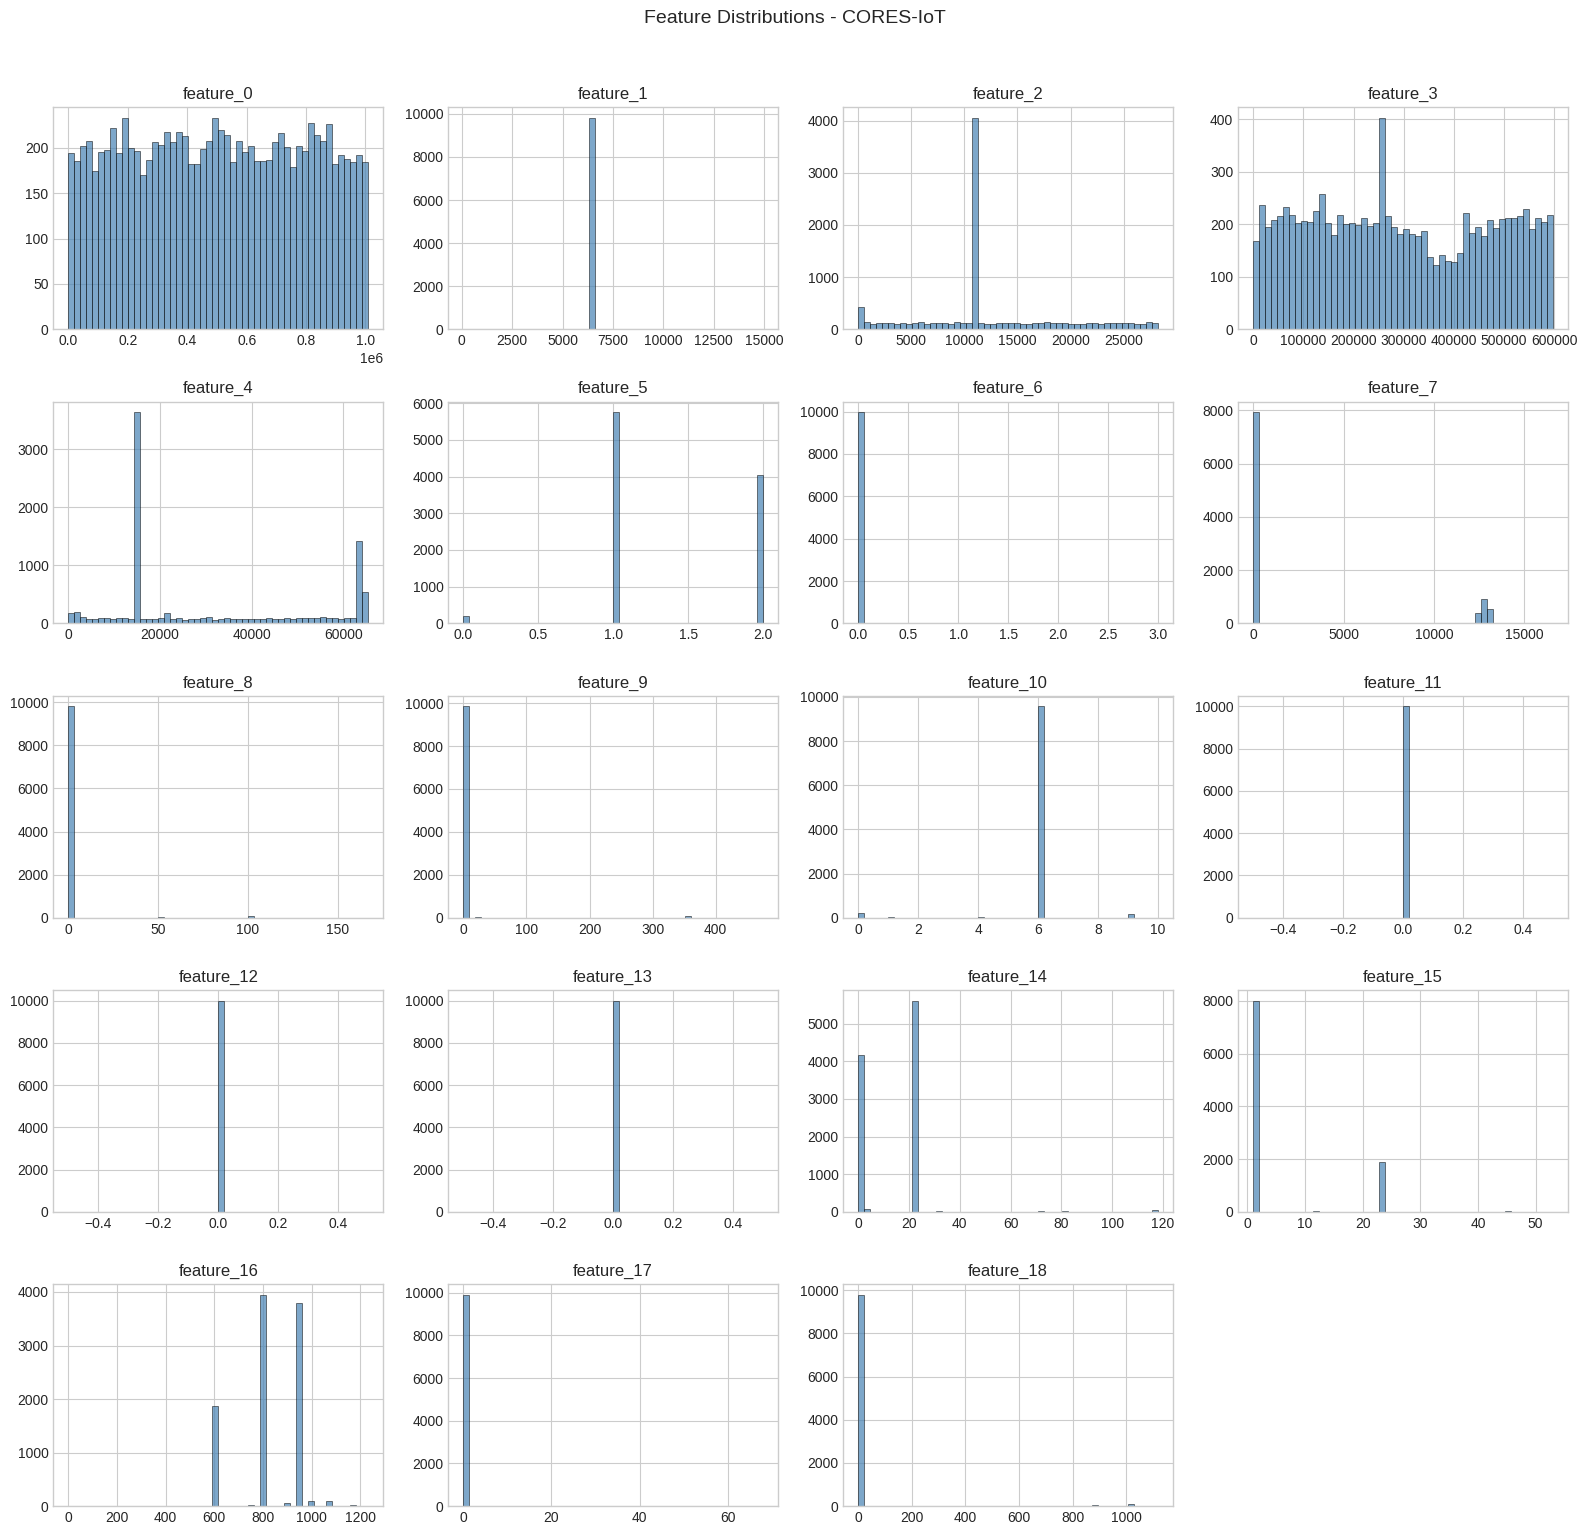

In [13]:
# Distribution plots for all features
n_cols = 4
n_rows = (len(feature_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    # Sample for faster plotting
    sample = df[col].sample(min(10000, len(df)), random_state=42)
    axes[i].hist(sample, bins=50, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions - CORES-IoT', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

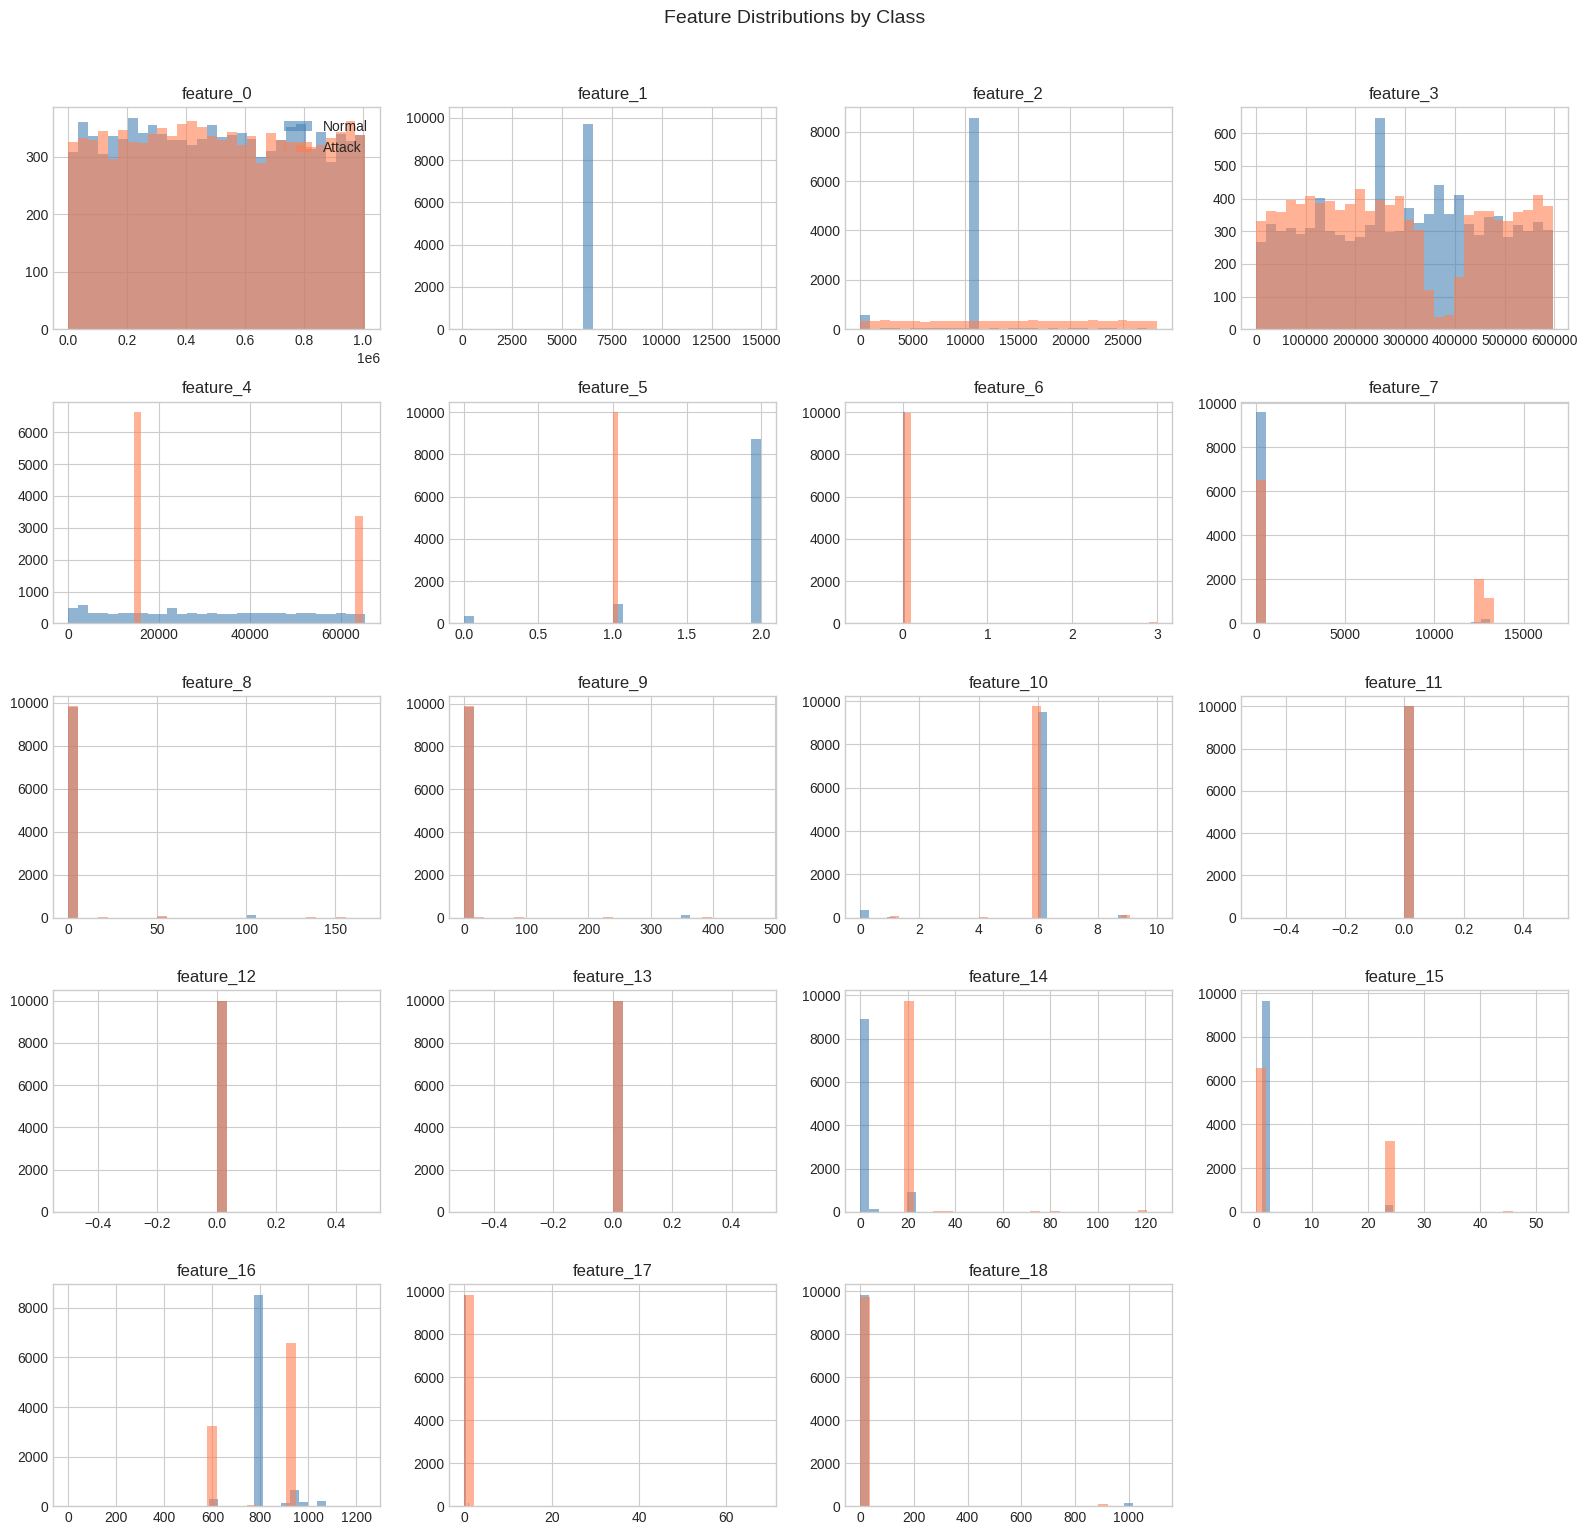

In [14]:
# Feature distributions by class
fig, axes = plt.subplots(5, 4, figsize=(16, 15))
axes = axes.flatten()

df_normal = df[df['ANOMALY'] == 0].sample(min(10000, (df['ANOMALY'] == 0).sum()), random_state=42)
df_attack = df[df['ANOMALY'] == 1].sample(min(10000, (df['ANOMALY'] == 1).sum()), random_state=42)

for i, col in enumerate(feature_cols):
    axes[i].hist(df_normal[col], bins=30, alpha=0.6, label='Normal', color='steelblue')
    axes[i].hist(df_attack[col], bins=30, alpha=0.6, label='Attack', color='coral')
    axes[i].set_title(f'{col}')
    if i == 0:
        axes[i].legend()

# Hide unused
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Class', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

In [15]:
print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

# Compute correlation matrix
df_sample = df.sample(min(100000, len(df)), random_state=42)
corr_matrix = df_sample[feature_cols].corr()

# Find highly correlated pairs
print("\n--- Highly Correlated Feature Pairs (|r| > 0.9) ---")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                r
            ))

if high_corr_pairs:
    for f1, f2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{f1} <-> {f2}: r = {r:.4f}")
else:
    print("No highly correlated pairs (|r| > 0.9) found.")

CORRELATION ANALYSIS

--- Highly Correlated Feature Pairs (|r| > 0.9) ---
feature_7 <-> feature_15: r = 0.9683


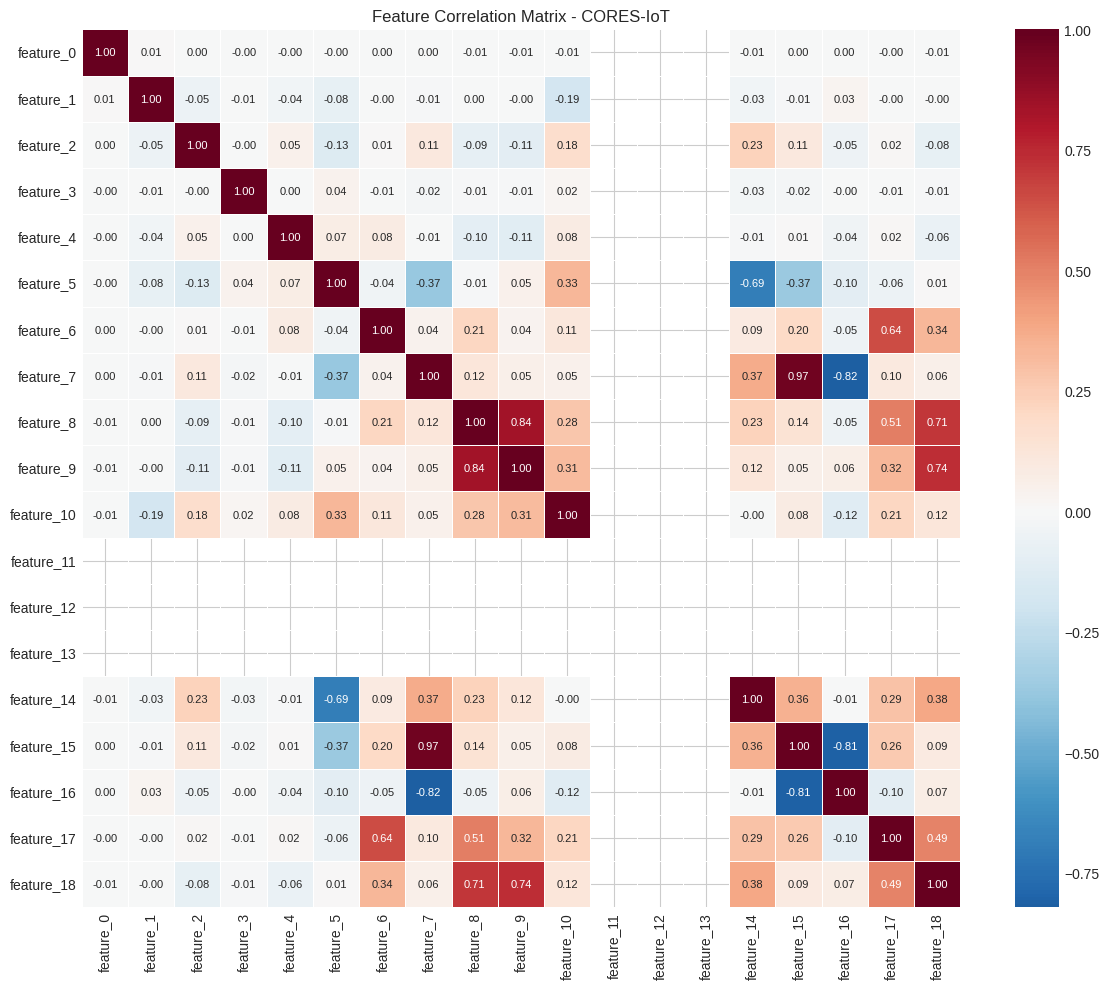

In [16]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=True, yticklabels=True, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Feature Correlation Matrix - CORES-IoT')
plt.tight_layout()
plt.show()

In [17]:
# Correlation with target
print("\n--- Feature Correlation with Target (ANOMALY) ---")
target_corr = df_sample.corr()['ANOMALY'].drop('ANOMALY').sort_values(key=abs, ascending=False)

print("\nAll features ranked by absolute correlation with ANOMALY:")
for feat, r in target_corr.items():
    direction = "↑" if r > 0 else "↓"
    print(f"  {feat}: r = {r:+.4f} {direction}")


--- Feature Correlation with Target (ANOMALY) ---

All features ranked by absolute correlation with ANOMALY:
  feature_5: r = -0.7914 ↓
  feature_14: r = +0.7394 ↑
  feature_7: r = +0.3835 ↑
  feature_15: r = +0.3788 ↑
  feature_2: r = +0.2548 ↑
  feature_10: r = +0.1019 ↑
  feature_17: r = +0.0721 ↑
  feature_6: r = +0.0511 ↑
  feature_9: r = -0.0358 ↓
  feature_1: r = -0.0316 ↓
  feature_3: r = -0.0309 ↓
  feature_16: r = +0.0272 ↑
  feature_4: r = -0.0123 ↓
  feature_18: r = +0.0074 ↑
  feature_8: r = +0.0031 ↑
  feature_0: r = +0.0006 ↑
  feature_11: r = +nan ↓
  feature_12: r = +nan ↓
  feature_13: r = +nan ↓


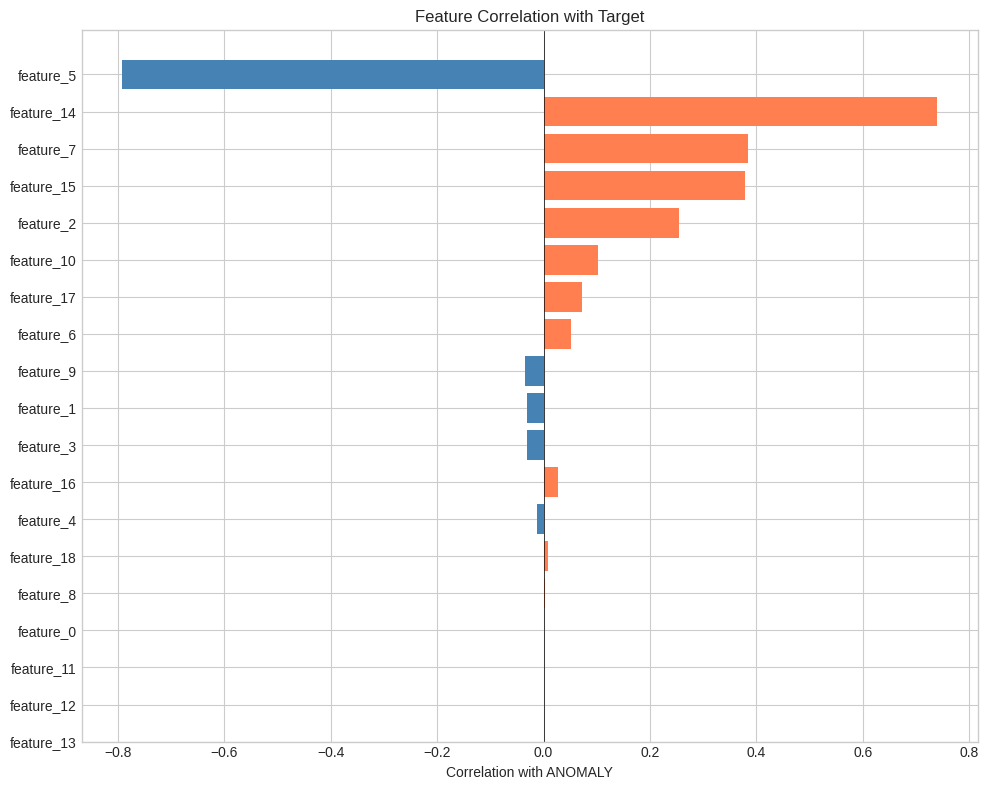

In [18]:
# Visualize correlation with target
plt.figure(figsize=(10, 8))
colors = ['coral' if x > 0 else 'steelblue' for x in target_corr.values]
plt.barh(range(len(target_corr)), target_corr.values, color=colors)
plt.yticks(range(len(target_corr)), target_corr.index)
plt.xlabel('Correlation with ANOMALY')
plt.title('Feature Correlation with Target')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Outlier Detection

In [19]:
print("=" * 60)
print("OUTLIER ANALYSIS")
print("=" * 60)

# IQR-based outlier detection
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((series < lower) | (series > upper)).sum()
    return outliers, outliers / len(series) * 100

print("\n--- Outlier Count per Feature (IQR method) ---")
outlier_stats = []
for col in feature_cols:
    count, pct = count_outliers_iqr(df[col])
    outlier_stats.append({'feature': col, 'outliers': count, 'percentage': pct})

outlier_df = pd.DataFrame(outlier_stats).sort_values('percentage', ascending=False)
print(outlier_df.to_string(index=False))

OUTLIER ANALYSIS

--- Outlier Count per Feature (IQR method) ---
   feature  outliers  percentage
 feature_7    212448   21.060562
 feature_9    212448   21.060562
 feature_8    212448   21.060562
feature_15    202024   20.027202
 feature_2    190670   18.901648
feature_10     37519    3.719363
feature_17     19894    1.972148
feature_18     19894    1.972148
 feature_1     17687    1.753362
feature_14     10072    0.998465
feature_16      5480    0.543248
 feature_6      3241    0.321289
 feature_0         0    0.000000
 feature_5         0    0.000000
 feature_3         0    0.000000
 feature_4         0    0.000000
feature_13         0    0.000000
feature_11         0    0.000000
feature_12         0    0.000000


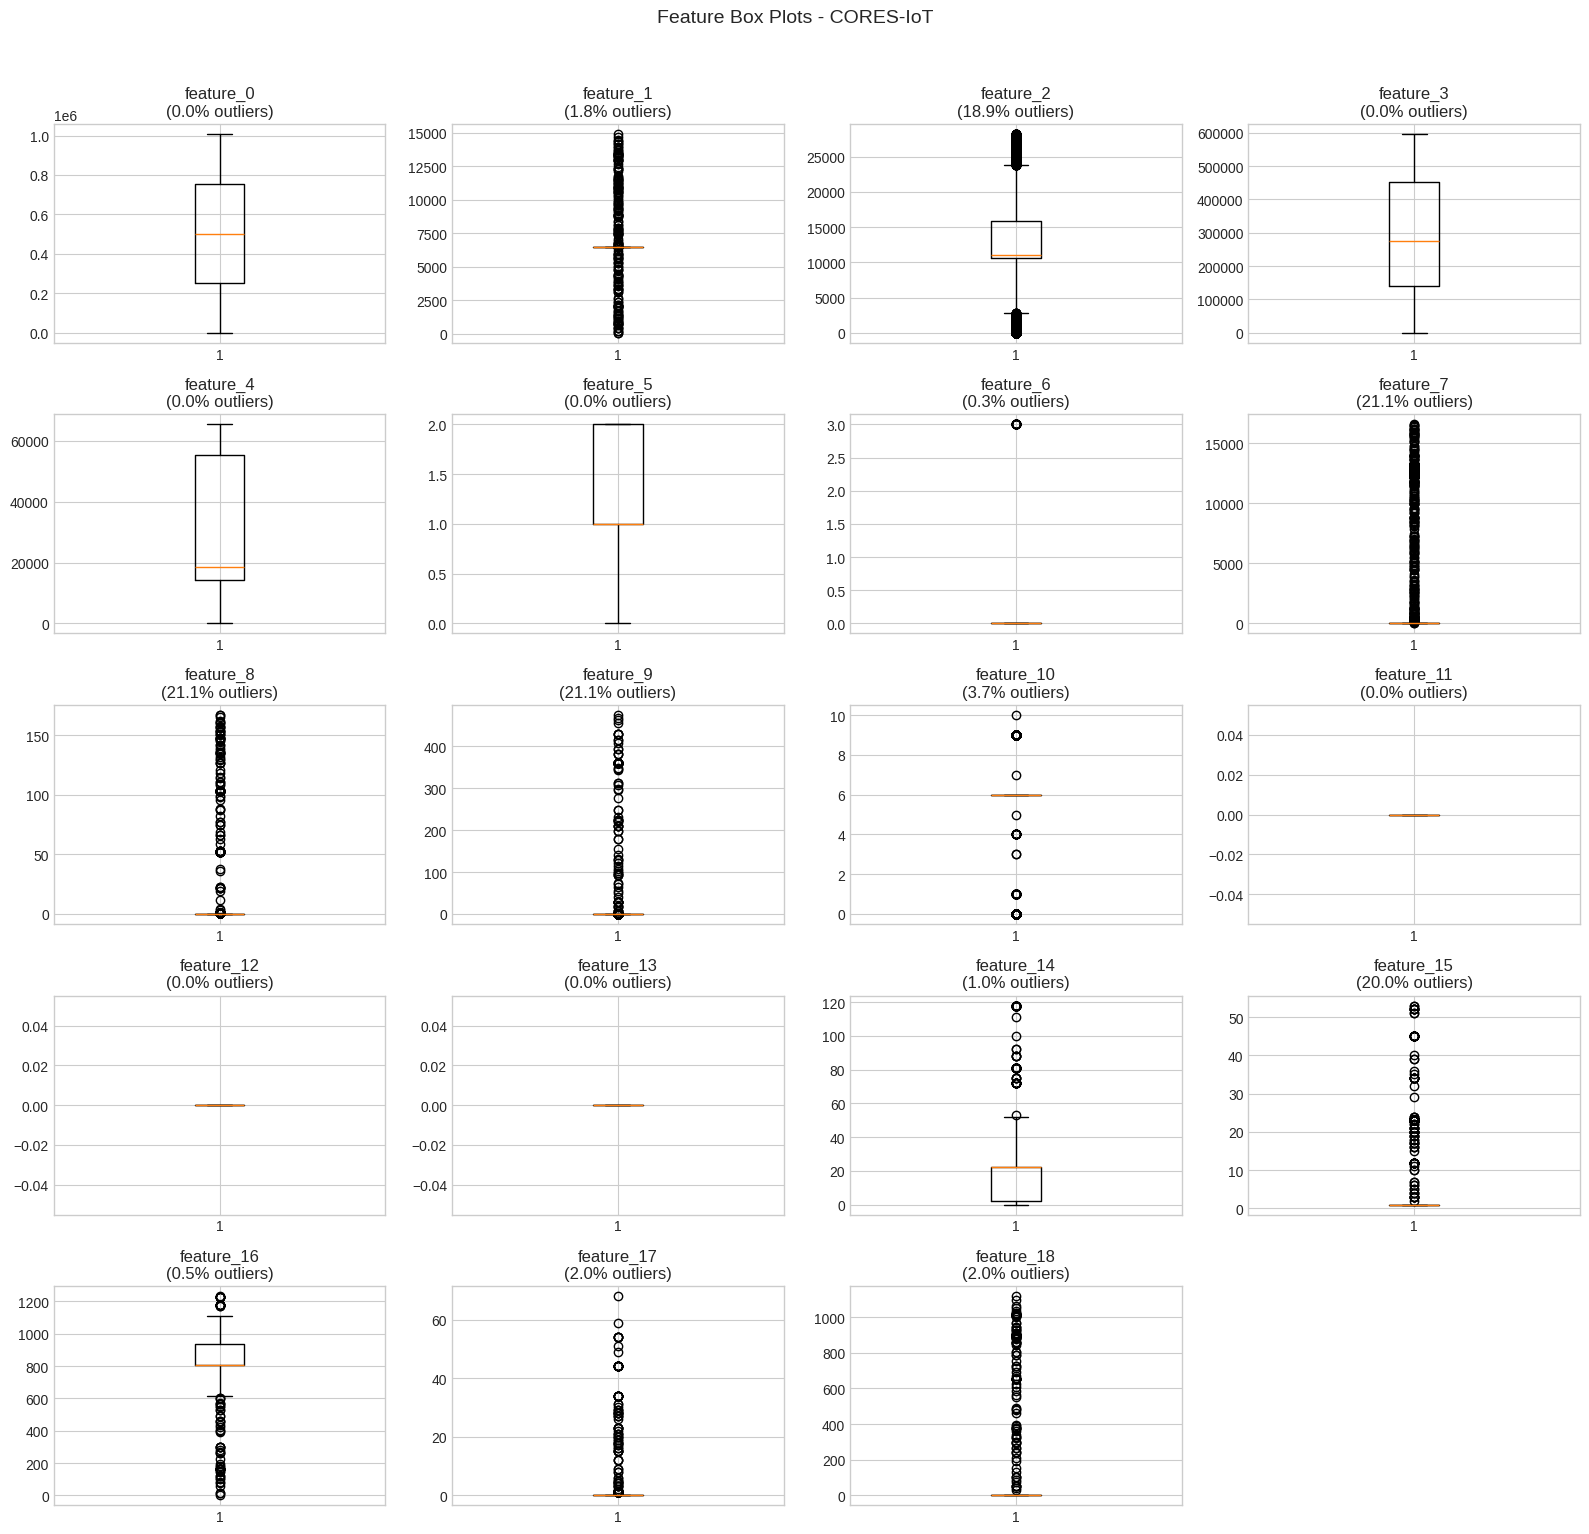

In [20]:
# Box plots for all features
n_cols = 4
n_rows = (len(feature_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sample = df[col].sample(min(10000, len(df)), random_state=42)
    axes[i].boxplot(sample, vert=True)
    outlier_pct = outlier_df[outlier_df['feature'] == col]['percentage'].values[0]
    axes[i].set_title(f'{col}\n({outlier_pct:.1f}% outliers)')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Box Plots - CORES-IoT', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 8. Feature Importance (Random Forest)

In [21]:
from sklearn.ensemble import RandomForestClassifier

print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

# Prepare data (sample for speed)
df_sample = df.sample(min(50000, len(df)), random_state=42)

X = df_sample[feature_cols]
y = df_sample['ANOMALY']

# Train Random Forest
print("\nTraining Random Forest for feature importance...")
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Feature importance
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance Ranking:")
print(importance.to_string(index=False))

FEATURE IMPORTANCE

Training Random Forest for feature importance...

Feature Importance Ranking:
   feature  importance
feature_14    0.306578
 feature_5    0.302621
 feature_4    0.139530
 feature_2    0.095813
feature_16    0.070012
 feature_7    0.033405
feature_15    0.020230
 feature_9    0.016787
 feature_8    0.006012
feature_10    0.004349
 feature_3    0.001656
 feature_1    0.001580
 feature_0    0.000822
feature_18    0.000360
feature_17    0.000237
 feature_6    0.000009
feature_13    0.000000
feature_11    0.000000
feature_12    0.000000


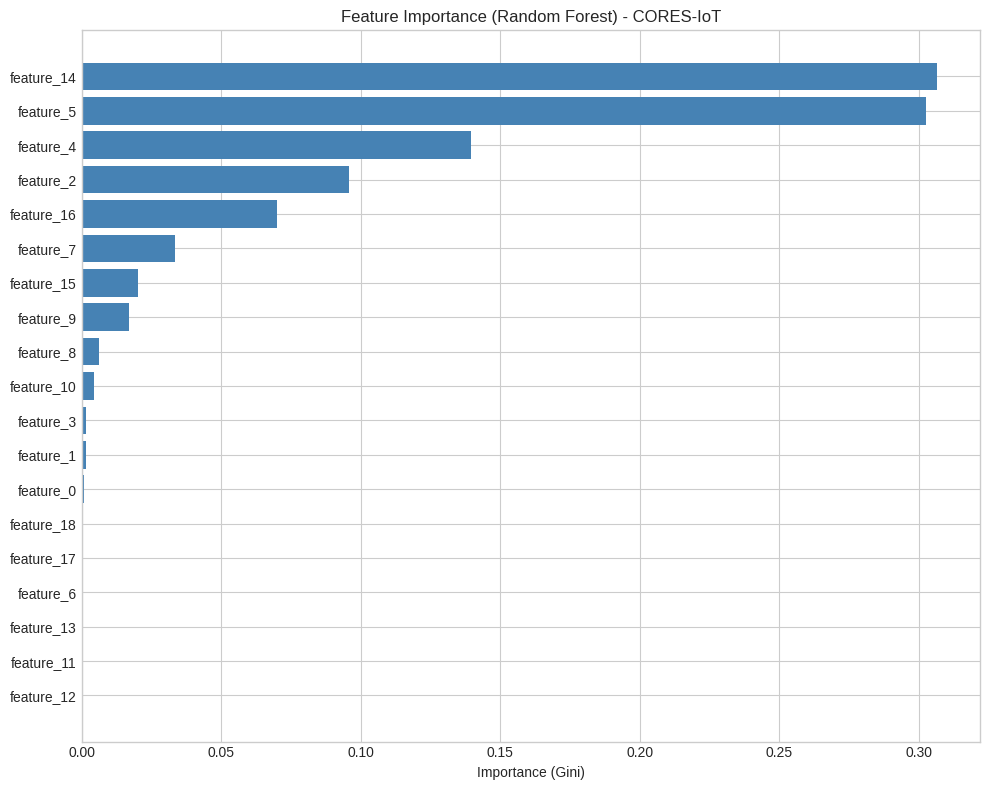

In [22]:
# Visualize feature importance
plt.figure(figsize=(10, 8))
plt.barh(range(len(importance)), importance['importance'].values, color='steelblue')
plt.yticks(range(len(importance)), importance['feature'].values)
plt.xlabel('Importance (Gini)')
plt.title('Feature Importance (Random Forest) - CORES-IoT')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()